In [264]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from vip_slap2_analysis.glutamate.summary import GlutamateSummary

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

In [66]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [67]:
%matplotlib notebook

In [68]:
datapath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-26_12-40-54\slap2\dynamic_data\ExperimentSummary\SummaryLoCo-260228-124246.mat"

In [69]:
f = h5py.File(datapath, "r")
E = f["exptSummary"]["E"]
print("E shape:", E.shape, "dtype:", E.dtype)

E shape: (2, 65) dtype: object


In [70]:
gs = GlutamateSummary(datapath, keep_open=True)
valid_trials_dmd1 = gs.valid_trials[0]
valid_trials_dmd2 = gs.valid_trials[1]
print(gs.n_synapses)          # list per DMD
print(gs.valid_trials[0])     # trials for DMD1

# Get dF/ls traces, all channels:
X = gs.get_traces(dmd=1, trial=valid_trials_dmd1[0], signal="dF",mode='ls', force_n_channels=2)

# X is (samples, rois, channels) OR (samples, rois) if single-channel

# Only green channel:
Xg = gs.get_traces(dmd=1, trial=valid_trials_dmd1[0], signal="dF", mode="ls", channels="green")

# User ROI traces (e.g. soma ROI):
U = gs.get_user_roi_traces(dmd=1, trial=valid_trials_dmd1[0], trace_type="F", channels=None)

# Summary image:
mean_im = gs.get_summary_image(dmd=1, image_type="meanIM")
act_im  = gs.get_summary_image(dmd=1, image_type="actIM")


[86, 42]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]


In [71]:
X.shape
# X[:,:,0]

(5539, 86, 2)

In [ ]:
# dmd0, trial0 = 0, 0  # DMD1, trial1
# g = gs._E_group(dmd0, trial0)

# print("Keys:", list(g.keys()))
# print("dF modes:", list(g["dF"].keys()) if "dF" in g else None)
# print("dF/ls shape:", g["dF"]["ls"].shape if "dF" in g and "ls" in g["dF"] else None)
# print("ROIs/F shape:", g["ROIs"]["F"].shape if "ROIs" in g and "F" in g["ROIs"] else None)

In [72]:
n_somas = gs.get_user_roi_traces(dmd=2,trial=1).shape[0]

soma_signals = [ [] for _ in range(n_somas) ]

for trial in gs.valid_trials[1]:
    traces = gs.get_user_roi_traces(dmd=2,trial=trial)
    for s in range(n_somas):
        soma_signals[s].append(traces[s,1,:])    # (n_samples,)
soma_signals = [np.concatenate(chunks, axis=0) for chunks in soma_signals]

<IPython.core.display.Javascript object>


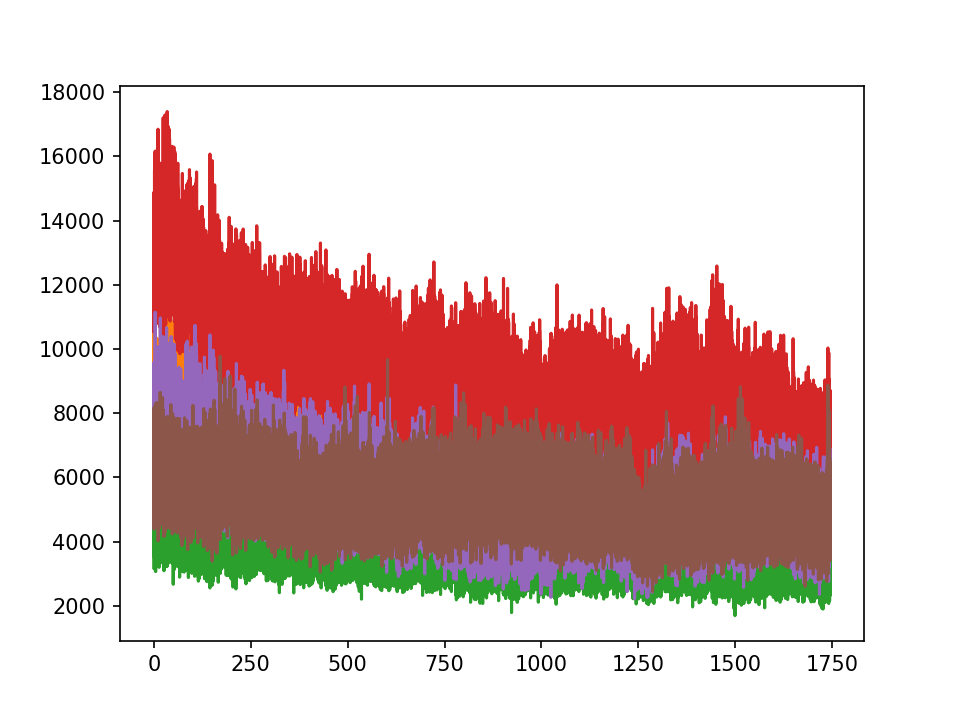

In [73]:
time = np.linspace(0,len(soma_signals[0])/200,len(soma_signals[0]))

fig,ax=plt.subplots()

for soma in soma_signals:
    ax.plot(time,soma)

In [205]:
out_all = gs.get_processed_soma_ca_all_trials(
    dmd=2,
    trace_type="Fsvd",
    fs_hz=gs.metadata["analyzeHz"],
    pad_to="ref",          # invalid trials get same length as ref
    include_invalid=True,
    unmix=True,
    baseline_window_s=10.0,
    baseline_q=10.0,
)

dff = out_all["dff"]  # shape: (n_trials, n_rois, T)

In [235]:
roi = 1
dff_cat = np.concatenate([dff[tr, roi] for tr in range(gs.n_trials)], axis=0)

<IPython.core.display.Javascript object>


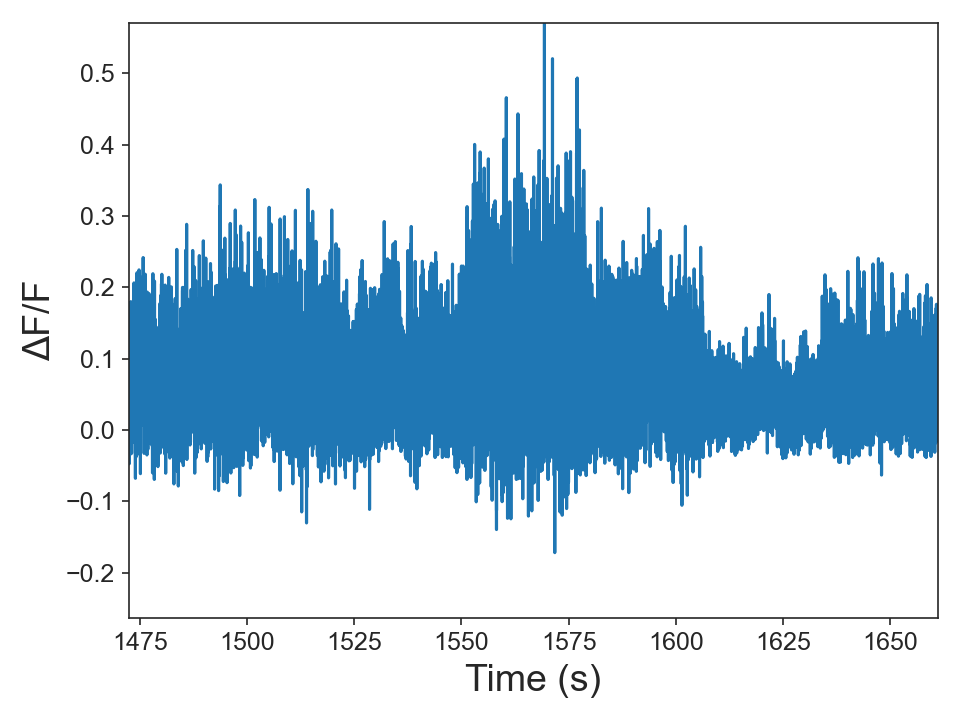

In [325]:
fig,ax=plt.subplots()

time = np.linspace(0,len(dff_cat)/200,len(dff_cat))

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

ax.plot(time,dff_cat)

ax.set_ylabel('\u0394F/F',fontsize=18)
ax.set_xlabel('Time (s)',fontsize=18)

fig.tight_layout()

<IPython.core.display.Javascript object>


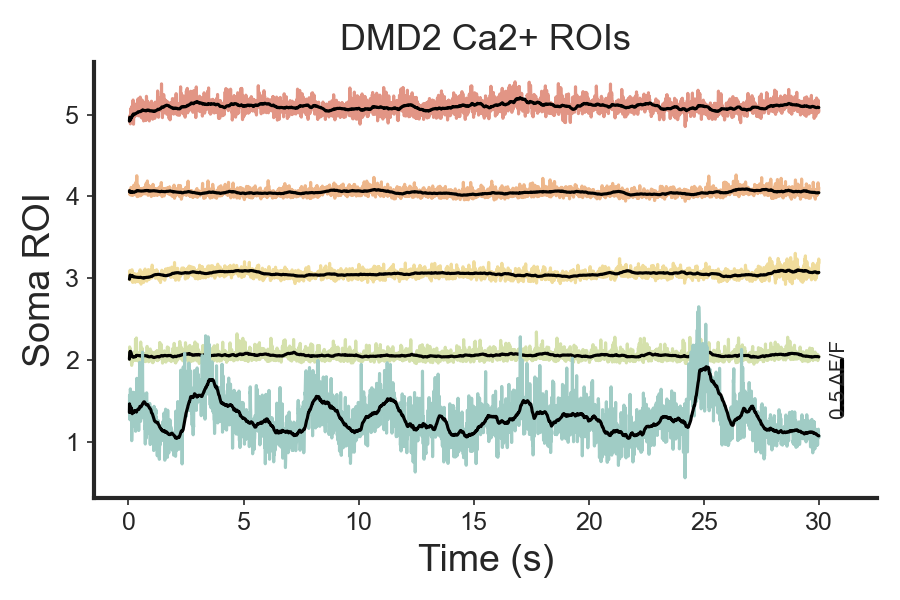

In [346]:
n_rois = np.shape(dff)[1]
offset = 0.75                   # you were using i/2
fs = 200                       # Hz

cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=n_rois)

fig, ax = plt.subplots(figsize=(6, 4))
sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

tw = [0,30]

for i in range(n_rois):
    # concatenate across trials for ROI i  -> (samples_total,)
    dff_ = np.concatenate([dff[tr, i] for tr in range(gs.n_trials)], axis=0)

    # If all NaN, skip plotting (but we’ll still label its tick below)
    if np.all(np.isnan(dff_)):
        continue

    time = np.arange(dff_.size) / fs

    y = dff_ + i * offset
    ax.plot(time[(time<=tw[1])&(time>tw[0])], y[(time<=tw[1])&(time>tw[0])], color=cp[i], zorder=10 - i)

    y_smooth = pd.Series(y).rolling(100, min_periods=1).mean().to_numpy()
    ax.plot(time[(time<=tw[1])&(time>tw[0])], y_smooth[(time<=tw[1])&(time>tw[0])], color='k', zorder=10 - i)

# Put ticks at the *offset positions*, labels are the ROI indices
yticks = np.arange(n_rois) * offset
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(n_rois))   # integer ROI indices, including 0

ax.set_ylabel('Soma ROI', fontsize=18)
ax.set_xlabel('Time (s)', fontsize=18)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)

s_bar_pad = 1    

ax.plot([tw[1]+s_bar_pad,tw[1]+s_bar_pad],[1,1.5],color='k',lw=2)
ax.text(tw[1]+s_bar_pad/2,1.0,'0.5 \u0394F/F',rotation=90)
ax.set_title('DMD2 Ca2+ ROIs')
fig.tight_layout()

In [303]:
mean_y[mean_y!=np.nan]

0.5632207871576141

In [296]:
mean_y

[nan, nan, nan, nan, nan, nan]

In [213]:
pd_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-26_12-40-54\behavior\VCO1_Behavior.harp\extracted_files\photodiode.pkl"
stim_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-26_12-40-54\behavior\VCO1_Behavior.harp\bonsai_event_log.csv"
photodiode_df = pd.read_pickle(pd_path)
stim_df = pd.read_csv(stim_path)

In [214]:
from pathlib import Path
from read_harp import HarpReader
from aind_ophys.ophys.slap2.preprocessing import detect_epochs_adaptive

harp_dir = Path(stim_path).parent
harp_handler = HarpReader(harp_dir)
df = harp_handler.reader.DigitalInputState.read()
df['time']=df.index
df = df.sort_values('time')
df = df.reset_index(drop=True)

In [215]:
acq_time = df['time']-df['time'].iloc[0]
acq_time = acq_time.values

In [216]:
print('Detecting imaging epochs...')
gap_thresh = 0.02

epochs = detect_epochs_adaptive(df,acq_time,min_duration=6,acq_type='continuous')

epochs = [list(epoch) for epoch in epochs]
for epoch in epochs:
    epoch[2] = epoch[2] + df['time'].iloc[0] - photodiode_df.index[0]
    epoch[3] = epoch[3] + df['time'].iloc[0] - photodiode_df.index[0]
print(f'Number of detected epochs: {len(epochs)}')
print(f'Average length of detected epochs: {np.mean([np.diff([e[2],e[3]]) for e in epochs])} seconds')

Detecting imaging epochs...
Number of detected epochs: 1
Average length of detected epochs: 1798.364575999789 seconds


In [217]:
epochs

[[1, 384370, 6.771744000259787, 1805.1363200000487]]

<IPython.core.display.Javascript object>


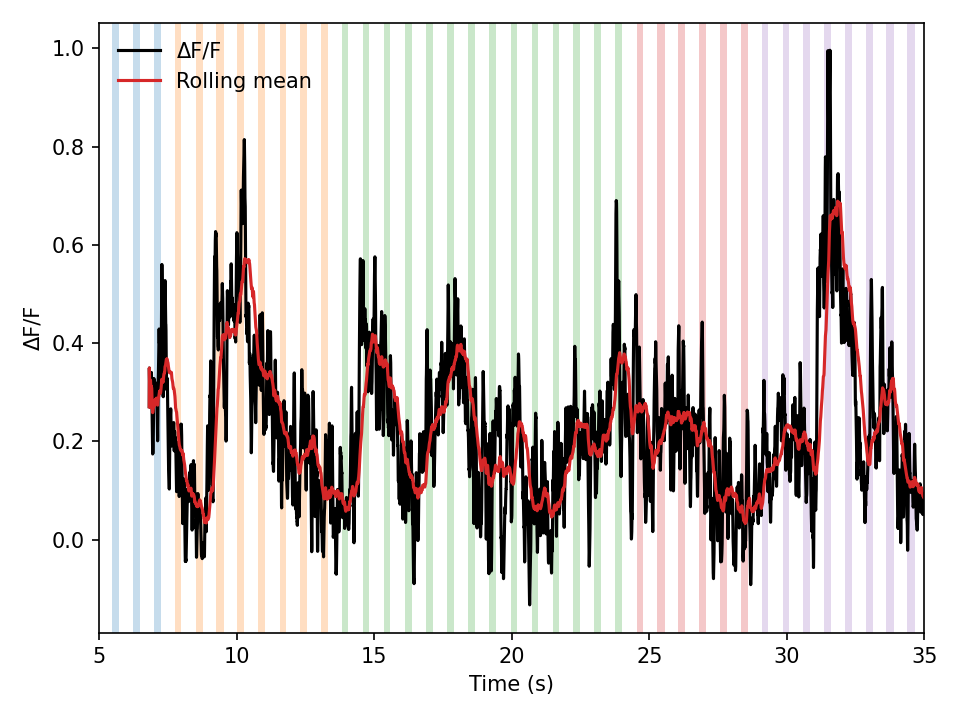

In [221]:
time = np.linspace(epochs[0][2],epochs[0][3],len(dff_cat))

fig,ax=plt.subplots()

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

for i,soma in enumerate(dff):
    if i==1:
        ax.plot(time,pd.DataFrame(dff_cat).rolling(10,min_periods=1).mean(),color='k',label='\u0394F/F')
        ax.plot(time,pd.DataFrame(dff_cat).rolling(100,min_periods=1).mean(),color='tab:red',label='Rolling mean')
# --- build a color map (stim_name -> color) using matplotlib's default cycle ---
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
stim_to_color = {}
color_i = 0
        
starts = stim_df[stim_df['Value'].astype(str).str.contains(r"\.tiff", case=False, na=False)].index

for i in starts[:50]:
    stim_name = str(stim_df.loc[i, 'Value'])  
    t_start = float(stim_df.loc[i, 'corrected_timestamps'])

    # find the next EndFlash after this start
    after = stim_df.loc[i+1:]
    end_rows = after[after['Value'].astype(str).str.contains("EndFlash", case=False, na=False)]
    if end_rows.empty:
        continue
    j = end_rows.index[0]
    t_end = float(stim_df.loc[j, 'corrected_timestamps'])

    # assign a color for this stimulus identity (filename string)
    if stim_name not in stim_to_color:
        stim_to_color[stim_name] = color_cycle[color_i % len(color_cycle)]
        color_i += 1

    ax.axvspan(t_start, t_end, alpha=0.25, color=stim_to_color[stim_name], lw=0)     

ax.set_xlim(5,35)

ax.set_ylabel('\u0394F/F',fontsize=18)
ax.set_xlabel('Time (s)',fontsize=18)
ax.legend(frameon=False)
fig.tight_layout()

In [220]:
len(starts)/1800

1.3127777777777778